
Using device: cpu | Training with Lambda (λ) = 0.0


100%|██████████| 170M/170M [00:05<00:00, 29.1MB/s] 


  Epoch 1/15 | Total Loss: 1.6393
  Epoch 2/15 | Total Loss: 1.4119
  Epoch 3/15 | Total Loss: 1.2928
  Epoch 4/15 | Total Loss: 1.1981
  Epoch 5/15 | Total Loss: 1.1095
  Epoch 6/15 | Total Loss: 1.0183
  Epoch 7/15 | Total Loss: 0.9374
  Epoch 8/15 | Total Loss: 0.8591
  Epoch 9/15 | Total Loss: 0.7874
  Epoch 10/15 | Total Loss: 0.7103
  Epoch 11/15 | Total Loss: 0.6435
  Epoch 12/15 | Total Loss: 0.5751
  Epoch 13/15 | Total Loss: 0.5218
  Epoch 14/15 | Total Loss: 0.4664
  Epoch 15/15 | Total Loss: 0.4164
  --> Final Test Accuracy: 54.01%
  --> Final Sparsity Level: 0.00%

Using device: cpu | Training with Lambda (λ) = 0.0001
  Epoch 1/15 | Total Loss: 147.9502
  Epoch 2/15 | Total Loss: 137.1524
  Epoch 3/15 | Total Loss: 122.1814
  Epoch 4/15 | Total Loss: 103.8322
  Epoch 5/15 | Total Loss: 84.6739
  Epoch 6/15 | Total Loss: 67.4092
  Epoch 7/15 | Total Loss: 53.3571
  Epoch 8/15 | Total Loss: 42.5140
  Epoch 9/15 | Total Loss: 34.3136
  Epoch 10/15 | Total Loss: 28.1135
  Epoc

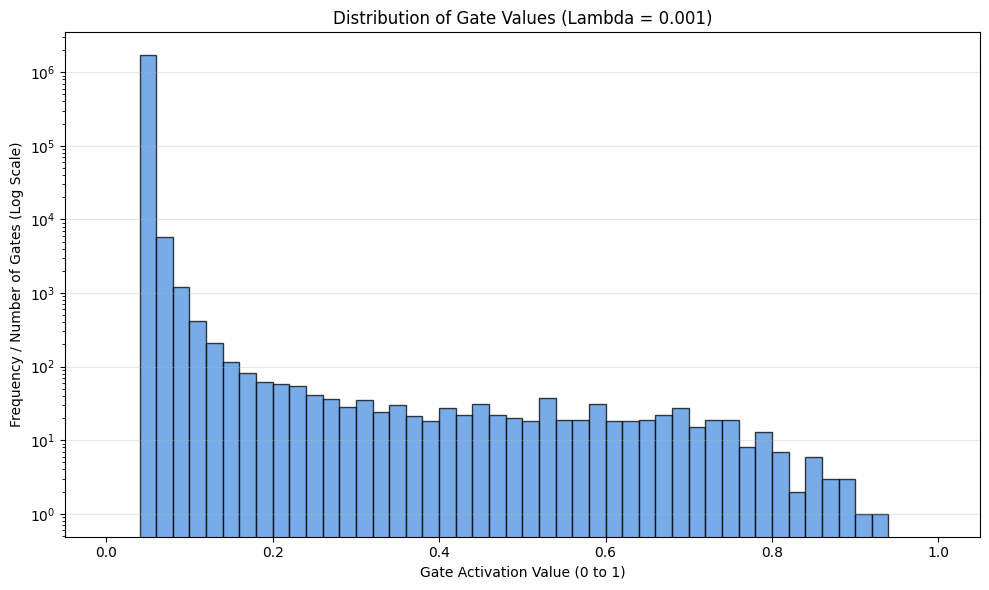

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------------
# Part 1: The "Prunable" Linear Layer
# -------------------------------------------------------------
class PrunableLinear(nn.Module):
    """
    A custom linear layer that implements self-pruning during training.
    """
    def __init__(self, in_features, out_features, bias=True):
        super(PrunableLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        
        # 1. Standard weight parameter
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        
        # 2. Optional bias parameter
        if bias:
            self.bias = nn.Parameter(torch.Tensor(out_features))
        else:
            self.register_parameter('bias', None)
            
        # 3. Learnable gate scores, same shape as weight
        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))
        
        # Initialize parameters
        self.reset_parameters()

    def reset_parameters(self):
        """
        Initialize weights, biases, and gate scores.
        """
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))
        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / np.sqrt(fan_in) if fan_in > 0 else 0
            nn.init.uniform_(self.bias, -bound, bound)
            
        # Initialize gate scores to a positive value (e.g., 2.0). 
        # This makes the initial sigmoid(gate_scores) close to 0.88,
        # starting the network with most weights active to allow standard learning initially.
        nn.init.constant_(self.gate_scores, 2.0)

    def forward(self, input):
        """
        Forward pass with gated pruning.
        """
        # Apply Sigmoid to turn gate scores into gates between 0 and 1
        gates = torch.sigmoid(self.gate_scores)
        
        # Element-wise multiplication to get pruned weights
        pruned_weights = self.weight * gates
        
        # Standard linear operation using the pruned weights
        return F.linear(input, pruned_weights, self.bias)

    def get_sparsity_loss(self):
        """
        Calculates the L1 norm of the gates for sparsity regularization.
        Because gates are outputs of Sigmoid, they are strictly positive, 
        so sum of gates is equivalent to the L1 norm.
        """
        gates = torch.sigmoid(self.gate_scores)
        return torch.sum(gates)

    def get_sparsity_level(self, threshold=1e-2):
        """
        Returns number of pruned weights and total number of weights.
        """
        gates = torch.sigmoid(self.gate_scores)
        pruned_count = torch.sum(gates < threshold).item()
        total_count = gates.numel()
        return pruned_count, total_count

# -------------------------------------------------------------
# Part 2: Model Definition
# -------------------------------------------------------------
class PrunableCIFARNet(nn.Module):
    """
    A simple Feed-Forward Neural Network for CIFAR-10 using PrunableLinear layers.
    """
    def __init__(self):
        super(PrunableCIFARNet, self).__init__()
        # Flattened CIFAR-10 image features: 3 channels * 32x32 pixels = 3072
        self.fc1 = PrunableLinear(3072, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        # Flatten the input image
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_total_sparsity_loss(self):
        """
        Accumulates the L1 sparsity loss across all PrunableLinear layers in the network.
        """
        loss = 0.0
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                loss += module.get_sparsity_loss()
        return loss

    def get_network_sparsity_level(self, threshold=1e-2):
        """
        Calculates the global percentage of pruned weights in the network.
        """
        total_pruned = 0
        total_weights = 0
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                pruned, total = module.get_sparsity_level(threshold)
                total_pruned += pruned
                total_weights += total
        return (total_pruned / total_weights) * 100 if total_weights > 0 else 0

# -------------------------------------------------------------
# Part 3: Training & Evaluation Loop
# -------------------------------------------------------------
def get_all_gates(model):
    """Utility function to extract all computed gate values from a model."""
    all_gates = []
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
            all_gates.extend(gates.flatten())
    return np.array(all_gates)

def train_and_evaluate(lam, epochs=10):
    """Trains the PrunableCIFARNet and evaluates it on the test set."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nUsing device: {device} | Training with Lambda (λ) = {lam}")
    
    # Load CIFAR-10 Data
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
    
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)
    
    model = PrunableCIFARNet().to(device)
    criterion = nn.CrossEntropyLoss()
    
    # We optimize ALL parameters: weights, biases, and gate_scores simultaneously
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(inputs)
            
            # 1. Classification Cross Entropy Loss
            cls_loss = criterion(outputs, labels)
            
            # 2. Sparsity Loss Penalty (L1 norm of all gates)
            sparsity_loss = model.get_total_sparsity_loss()
            
            # 3. Total Loss Objective Formula: ClassificationLoss + λ * SparsityLoss
            loss = cls_loss + lam * sparsity_loss
            
            # Backward pass & optimization
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        print(f"  Epoch {epoch+1}/{epochs} | Total Loss: {running_loss/len(trainloader):.4f}")
        
    # Evaluation Phase
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = 100 * correct / total
    sparsity_level = model.get_network_sparsity_level()
    
    print(f"  --> Final Test Accuracy: {accuracy:.2f}%")
    print(f"  --> Final Sparsity Level: {sparsity_level:.2f}%")
    
    return model, accuracy, sparsity_level

if __name__ == "__main__":
    # Test for 3 different values of lambda to observe the Sparsity vs. Accuracy trade-off
    lambdas = [0.0, 1e-4, 1e-3]
    epochs_to_train = 15  # 15 epochs gives it enough time to converge and prune
    
    results = []
    models = {}
    
    for lam in lambdas:
        model, acc, sparsity = train_and_evaluate(lam, epochs=epochs_to_train)
        results.append((lam, acc, sparsity))
        models[lam] = model
        
    # -------------------------------------------------------------
    # Final Report & Visualizations
    # -------------------------------------------------------------
    print("\n" + "="*50)
    print("=== FINAL TRADE-OFF REPORT ===")
    print("="*50)
    print(f"{'Lambda (λ)':<12} | {'Test Acc (%)':<15} | {'Sparsity Level (%)'}")
    print("-" * 50)
    for lam, acc, sparsity in results:
        print(f"{lam:<12} | {acc:<15.2f} | {sparsity:.2f}%")
        
    # Generate distribution plot for our sparsest model (Lambda = 1e-3)
    best_lam = 1e-3
    if best_lam in models:
        best_model = models[best_lam]
        all_gates = get_all_gates(best_model)
        
        plt.figure(figsize=(10, 6))
        plt.hist(all_gates, bins=50, range=(0, 1), alpha=0.75, color='#4A90E2', edgecolor='black')
        plt.title(f'Distribution of Gate Values (Lambda = {best_lam})')
        plt.xlabel('Gate Activation Value (0 to 1)')
        plt.ylabel('Frequency / Number of Gates (Log Scale)')
        plt.yscale('log')
        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()  # Displays inline in Jupyter / Kaggle

Using device: cpu

  Experiment: λ = 1e-05
  Epoch [01/30] Loss: 12.0718  Train Acc: 29.09%
  Epoch [02/30] Loss: 10.9092  Train Acc: 35.66%
  Epoch [03/30] Loss: 10.4248  Train Acc: 38.31%
  Epoch [04/30] Loss: 10.2781  Train Acc: 39.65%
  Epoch [05/30] Loss: 10.2285  Train Acc: 40.97%
  Epoch [06/30] Loss: 10.2002  Train Acc: 41.81%
  Epoch [07/30] Loss: 10.1831  Train Acc: 42.34%
  Epoch [08/30] Loss: 10.1638  Train Acc: 43.05%
  Epoch [09/30] Loss: 10.1474  Train Acc: 43.63%
  Epoch [10/30] Loss: 10.1345  Train Acc: 44.08%
  Epoch [11/30] Loss: 10.1246  Train Acc: 44.54%
  Epoch [12/30] Loss: 10.1108  Train Acc: 44.82%
  Epoch [13/30] Loss: 10.1002  Train Acc: 45.32%
  Epoch [14/30] Loss: 10.0891  Train Acc: 45.64%
  Epoch [15/30] Loss: 10.0804  Train Acc: 45.84%
  Epoch [16/30] Loss: 10.0677  Train Acc: 46.67%
  Epoch [17/30] Loss: 10.0584  Train Acc: 46.58%
  Epoch [18/30] Loss: 10.0497  Train Acc: 47.37%
  Epoch [19/30] Loss: 10.0392  Train Acc: 47.30%
  Epoch [20/30] Loss: 10.0

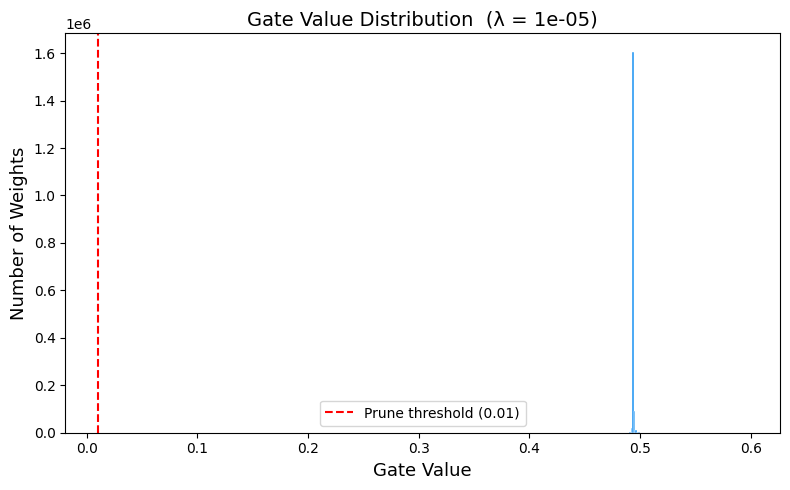

In [4]:
"""
Self-Pruning Neural Network on CIFAR-10
========================================
Author : Your Name
Task   : Tredence AI Engineering Internship Case Study

What this code does (plain English):
  - We build a normal neural network for image classification.
  - BUT every weight has a "gate" attached to it (a number between 0 and 1).
  - If a gate goes to 0, that weight is effectively removed (pruned).
  - We train the network to push most gates to 0 automatically, making the
    network smaller while keeping accuracy as high as possible.
"""

# ── Standard / third-party imports ─────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# ── Reproducibility ─────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── Device: use GPU if available, else CPU ───────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


# ════════════════════════════════════════════════════════════════════════════
# PART 1 – PrunableLinear Layer
# ════════════════════════════════════════════════════════════════════════════

class PrunableLinear(nn.Module):
    """
    A custom linear (fully-connected) layer that can prune its own weights.

    How it works:
      - Normal linear layer: output = input @ weight.T + bias
      - Our layer       : output = input @ (weight * gate).T + bias
        where gate = sigmoid(gate_scores)   ← learned during training

    Because sigmoid always outputs values between 0 and 1:
      - gate ≈ 0  →  weight is effectively removed (pruned)
      - gate ≈ 1  →  weight is kept as-is

    The sparsity loss (defined later) pushes most gates toward 0.
    """

    def __init__(self, in_features: int, out_features: int):
        super().__init__()

        # Standard learnable weight matrix  shape: (out_features, in_features)
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))

        # Standard learnable bias  shape: (out_features,)
        self.bias = nn.Parameter(torch.Tensor(out_features))

        # Gate scores – same shape as weight – also learnable
        # These are raw (unconstrained) numbers; we pass them through
        # sigmoid in forward() to squeeze them into [0, 1].
        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))

        # Initialise weights with Kaiming uniform (good default for ReLU nets)
        nn.init.kaiming_uniform_(self.weight, nonlinearity="relu")
        nn.init.zeros_(self.bias)
        # Initialise gate_scores to a small positive value so gates start ≈ 0.7
        # This gives the network room to move in both directions.
        nn.init.constant_(self.gate_scores, 0.5)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Step 1 – squeeze gate_scores into [0, 1]
        gates = torch.sigmoid(self.gate_scores)

        # Step 2 – element-wise multiply: prune weak weights
        pruned_weights = self.weight * gates

        # Step 3 – standard linear operation  (same as F.linear)
        return x @ pruned_weights.T + self.bias

    def get_gates(self) -> torch.Tensor:
        """Return the current gate values (useful for analysis)."""
        return torch.sigmoid(self.gate_scores).detach()


# ════════════════════════════════════════════════════════════════════════════
# Network Definition
# ════════════════════════════════════════════════════════════════════════════

class SelfPruningNet(nn.Module):
    """
    A simple feed-forward network made of PrunableLinear layers.

    Architecture:
      Input (3×32×32 = 3072 floats)
        → PrunableLinear(3072, 512) → BatchNorm → ReLU → Dropout
        → PrunableLinear(512,  256) → BatchNorm → ReLU → Dropout
        → PrunableLinear(256,  128) → BatchNorm → ReLU → Dropout
        → PrunableLinear(128,   10) → (logits, no activation)

    CIFAR-10 has 10 classes, so the last layer has 10 outputs.
    """

    def __init__(self, dropout_rate: float = 0.3):
        super().__init__()

        self.net = nn.Sequential(
            # Block 1
            PrunableLinear(3 * 32 * 32, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Block 2
            PrunableLinear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Block 3
            PrunableLinear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Output layer (no activation – CrossEntropyLoss handles softmax)
            PrunableLinear(128, 10),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Flatten the image: (batch, 3, 32, 32) → (batch, 3072)
        x = x.view(x.size(0), -1)
        return self.net(x)

    def prunable_layers(self):
        """Yield every PrunableLinear layer inside the network."""
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                yield module


# ════════════════════════════════════════════════════════════════════════════
# PART 2 – Sparsity Loss
# ════════════════════════════════════════════════════════════════════════════

def sparsity_loss(model: SelfPruningNet) -> torch.Tensor:
    """
    L1 penalty on all gate values.

    Why L1 encourages sparsity (plain English):
      - L1 = sum of absolute values of gates
      - The gradient of |gate| is always ±1 (constant push toward 0)
      - This gives every gate a constant "nudge" downward
      - Unlike L2 (which slows down near 0), L1 keeps pushing until the gate
        actually hits 0 → true sparsity

    Returns a scalar tensor (the sum of all gate values across all layers).
    """
    total = torch.tensor(0.0, device=DEVICE)
    for layer in model.prunable_layers():
        gates = torch.sigmoid(layer.gate_scores)
        total = total + gates.sum()          # all gates are positive, so |gate| = gate
    return total


# ════════════════════════════════════════════════════════════════════════════
# PART 3 – Data Loading
# ════════════════════════════════════════════════════════════════════════════

def get_dataloaders(batch_size: int = 128):
    """
    Download CIFAR-10 and return train / test DataLoaders.

    Transforms applied:
      Training  : random crop + horizontal flip (data augmentation) + normalize
      Test      : only normalize (no augmentation → fair evaluation)
    """
    # CIFAR-10 mean and std (per channel) – standard values
    mean = (0.4914, 0.4822, 0.4465)
    std  = (0.2023, 0.1994, 0.2010)

    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    train_set = torchvision.datasets.CIFAR10(
        root="./data", train=True,  download=True, transform=train_transform
    )
    test_set  = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True, transform=test_transform
    )

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)

    return train_loader, test_loader


# ════════════════════════════════════════════════════════════════════════════
# Training Loop
# ════════════════════════════════════════════════════════════════════════════

def train(model, train_loader, optimizer, scheduler, lam: float, epochs: int):
    """
    Train the model for a given number of epochs.

    Total Loss = CrossEntropyLoss + λ × SparsityLoss

    Parameters
    ----------
    model        : SelfPruningNet
    train_loader : DataLoader
    optimizer    : e.g. Adam
    scheduler    : learning-rate scheduler
    lam          : λ – controls how hard we push sparsity
    epochs       : number of training epochs
    """
    criterion = nn.CrossEntropyLoss()
    model.train()

    for epoch in range(1, epochs + 1):
        running_loss = 0.0
        correct = 0
        total   = 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()

            # Forward pass
            logits = model(images)

            # Classification loss
            cls_loss = criterion(logits, labels)

            # Sparsity regularisation
            spar_loss = sparsity_loss(model)

            # Combined loss
            loss = cls_loss + lam * spar_loss

            # Backward pass – gradients flow through both weight & gate_scores
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

        scheduler.step()

        train_acc = 100.0 * correct / total
        print(f"  Epoch [{epoch:02d}/{epochs}] "
              f"Loss: {running_loss / len(train_loader):.4f}  "
              f"Train Acc: {train_acc:.2f}%")


# ════════════════════════════════════════════════════════════════════════════
# Evaluation
# ════════════════════════════════════════════════════════════════════════════

def evaluate(model, test_loader):
    """Return test accuracy (%) on the given DataLoader."""
    model.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            preds = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    return 100.0 * correct / total


def compute_sparsity(model, threshold: float = 1e-2) -> float:
    """
    Compute the percentage of weights whose gate value is below `threshold`.

    A gate below the threshold is considered "pruned / dead".

    Returns a float between 0 and 100.
    """
    total_gates  = 0
    pruned_gates = 0

    for layer in model.prunable_layers():
        gates = layer.get_gates()
        total_gates  += gates.numel()
        pruned_gates += (gates < threshold).sum().item()

    return 100.0 * pruned_gates / total_gates


# ════════════════════════════════════════════════════════════════════════════
# Gate Distribution Plot
# ════════════════════════════════════════════════════════════════════════════

def plot_gate_distribution(model, lam: float, save_path: str = None):
    """
    Plot a histogram of all final gate values.

    A well-trained model will show:
      - A large spike near 0  (pruned weights)
      - A smaller cluster near 1  (important weights that survived)
    """
    all_gates = []
    for layer in model.prunable_layers():
        all_gates.append(layer.get_gates().cpu().numpy().flatten())

    all_gates = np.concatenate(all_gates)

    plt.figure(figsize=(8, 5))
    plt.hist(all_gates, bins=80, color="#2196F3", edgecolor="white", linewidth=0.3)
    plt.xlabel("Gate Value", fontsize=13)
    plt.ylabel("Number of Weights", fontsize=13)
    plt.title(f"Gate Value Distribution  (λ = {lam})", fontsize=14)
    plt.axvline(x=0.01, color="red", linestyle="--", label="Prune threshold (0.01)")
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"  Plot saved → {save_path}")
    plt.show()


# ════════════════════════════════════════════════════════════════════════════
# Main – Run experiments for multiple λ values
# ════════════════════════════════════════════════════════════════════════════

def run_experiment(lam: float, train_loader, test_loader, epochs: int = 30):
    """
    Full train → evaluate cycle for one value of λ.

    Returns (test_accuracy, sparsity_level, trained_model)
    """
    print(f"\n{'='*60}")
    print(f"  Experiment: λ = {lam}")
    print(f"{'='*60}")

    model = SelfPruningNet(dropout_rate=0.3).to(DEVICE)

    # Adam with weight decay (L2) on the weights; sparsity loss handles gates
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    # Cosine annealing gradually lowers the learning rate → smoother convergence
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train(model, train_loader, optimizer, scheduler, lam=lam, epochs=epochs)

    test_acc = evaluate(model, test_loader)
    sparsity = compute_sparsity(model)

    print(f"\n  ✔ Test Accuracy  : {test_acc:.2f}%")
    print(f"  ✔ Sparsity Level : {sparsity:.2f}%  (gates < 0.01)")

    return test_acc, sparsity, model


def main():
    EPOCHS     = 30          # increase to 50+ for better accuracy
    BATCH_SIZE = 128

    # Three λ values: low, medium, high
    lambda_values = [1e-5, 1e-4, 1e-3]

    train_loader, test_loader = get_dataloaders(batch_size=BATCH_SIZE)

    results = {}   # lam → (test_acc, sparsity, model)

    for lam in lambda_values:
        acc, spar, model = run_experiment(lam, train_loader, test_loader, EPOCHS)
        results[lam] = (acc, spar, model)

    # ── Summary Table ────────────────────────────────────────────────────────
    print("\n" + "="*55)
    print(f"{'Lambda':<12} {'Test Accuracy':>15} {'Sparsity (%)':>15}")
    print("="*55)
    for lam, (acc, spar, _) in results.items():
        print(f"{lam:<12} {acc:>14.2f}% {spar:>14.2f}%")
    print("="*55)

    # ── Gate Distribution Plot for best model (highest accuracy) ─────────────
    best_lam = max(results, key=lambda l: results[l][0])
    best_model = results[best_lam][2]
    print(f"\nPlotting gate distribution for best model (λ = {best_lam}) …")
    plot_gate_distribution(best_model, lam=best_lam,
                           save_path="gate_distribution.png")


if __name__ == "__main__":
    main()

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------------
# Part 1: The "Prunable" Linear Layer
# -------------------------------------------------------------
class PrunableLinear(nn.Module):
    """
    A custom linear layer that implements self-pruning during training.
    """
    def __init__(self, in_features, out_features, bias=True):
        super(PrunableLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        
        # 1. Standard weight parameter
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))
        
        # 2. Optional bias parameter
        if bias:
            self.bias = nn.Parameter(torch.Tensor(out_features))
        else:
            self.register_parameter('bias', None)
            
        # 3. Learnable gate scores, same shape as weight
        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))
        
        # Initialize parameters
        self.reset_parameters()

    def reset_parameters(self):
        """
        Initialize weights, biases, and gate scores.
        """
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))
        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / np.sqrt(fan_in) if fan_in > 0 else 0
            nn.init.uniform_(self.bias, -bound, bound)
            
        # Initialize gate scores to a smaller value (e.g., 0.5). 
        # This makes it easier for the L1 penalty to push the value negative,
        # effectively pruning the weight if it's not useful.
        nn.init.constant_(self.gate_scores, 0.5)

    def forward(self, input):
        """
        Forward pass with gated pruning.
        """
        # Apply Sigmoid to turn gate scores into gates between 0 and 1
        gates = torch.sigmoid(self.gate_scores)
        
        # Element-wise multiplication to get pruned weights
        pruned_weights = self.weight * gates
        
        # Standard linear operation using the pruned weights
        return F.linear(input, pruned_weights, self.bias)

    def get_sparsity_loss(self):
        """
        Calculates the L1 norm of the gates for sparsity regularization.
        Because gates are outputs of Sigmoid, they are strictly positive, 
        so sum of gates is equivalent to the L1 norm.
        """
        gates = torch.sigmoid(self.gate_scores)
        return torch.sum(gates)

    def get_sparsity_level(self, threshold=1e-2):
        """
        Returns number of pruned weights and total number of weights.
        """
        gates = torch.sigmoid(self.gate_scores)
        pruned_count = torch.sum(gates < threshold).item()
        total_count = gates.numel()
        return pruned_count, total_count

# -------------------------------------------------------------
# Part 2: Model Definition
# -------------------------------------------------------------
class PrunableCIFARNet(nn.Module):
    """
    A simple Feed-Forward Neural Network for CIFAR-10 using PrunableLinear layers.
    """
    def __init__(self):
        super(PrunableCIFARNet, self).__init__()
        # Flattened CIFAR-10 image features: 3 channels * 32x32 pixels = 3072
        self.fc1 = PrunableLinear(3072, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        # Flatten the input image
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_total_sparsity_loss(self):
        """
        Accumulates the L1 sparsity loss across all PrunableLinear layers in the network.
        """
        loss = 0.0
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                loss += module.get_sparsity_loss()
        return loss

    def get_network_sparsity_level(self, threshold=1e-2):
        """
        Calculates the global percentage of pruned weights in the network.
        """
        total_pruned = 0
        total_weights = 0
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                pruned, total = module.get_sparsity_level(threshold)
                total_pruned += pruned
                total_weights += total
        return (total_pruned / total_weights) * 100 if total_weights > 0 else 0

# -------------------------------------------------------------
# Part 3: Training & Evaluation Loop
# -------------------------------------------------------------
def get_all_gates(model):
    """Utility function to extract all computed gate values from a model."""
    all_gates = []
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy()
            all_gates.extend(gates.flatten())
    return np.array(all_gates)

def train_and_evaluate(lam, epochs=10):
    """Trains the PrunableCIFARNet and evaluates it on the test set."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nUsing device: {device} | Training with Lambda (λ) = {lam}")
    
    # Load CIFAR-10 Data
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
    
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)
    
    model = PrunableCIFARNet().to(device)
    criterion = nn.CrossEntropyLoss()
    
    # We optimize ALL parameters: weights, biases, and gate_scores simultaneously
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(inputs)
            
            # 1. Classification Cross Entropy Loss
            cls_loss = criterion(outputs, labels)
            
            # 2. Sparsity Loss Penalty (L1 norm of all gates)
            sparsity_loss = model.get_total_sparsity_loss()
            
            # 3. Total Loss Objective Formula: ClassificationLoss + λ * SparsityLoss
            loss = cls_loss + lam * sparsity_loss
            
            # Backward pass & optimization
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        print(f"  Epoch {epoch+1}/{epochs} | Total Loss: {running_loss/len(trainloader):.4f}")
        
    # Evaluation Phase
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = 100 * correct / total
    sparsity_level = model.get_network_sparsity_level()
    
    print(f"  --> Final Test Accuracy: {accuracy:.2f}%")
    print(f"  --> Final Sparsity Level: {sparsity_level:.2f}%")
    
    return model, accuracy, sparsity_level

if __name__ == "__main__":
    # Test for 3 different values of lambda to observe the Sparsity vs. Accuracy trade-off
    # Increased lambdas to properly force sparsity
    lambdas = [0.0, 0.01, 0.1]
    epochs_to_train = 15
    
    results = []
    models = {}
    
    for lam in lambdas:
        model, acc, sparsity = train_and_evaluate(lam, epochs=epochs_to_train)
        results.append((lam, acc, sparsity))
        models[lam] = model
        
    # -------------------------------------------------------------
    # Final Report & Visualizations
    # -------------------------------------------------------------
    print("\n" + "="*50)
    print("=== FINAL TRADE-OFF REPORT ===")
    print("="*50)
    print(f"{'Lambda (λ)':<12} | {'Test Acc (%)':<15} | {'Sparsity Level (%)'}")
    print("-" * 50)
    for lam, acc, sparsity in results:
        print(f"{lam:<12} | {acc:<15.2f} | {sparsity:.2f}%")
        
    # Generate distribution plot for our sparsest model
    best_lam = 0.1
    if best_lam in models:
        best_model = models[best_lam]
        all_gates = get_all_gates(best_model)
        
        plt.figure(figsize=(10, 6))
        plt.hist(all_gates, bins=50, range=(0, 1), alpha=0.75, color='#4A90E2', edgecolor='black')
        plt.title(f'Distribution of Gate Values (Lambda = {best_lam})')
        plt.xlabel('Gate Activation Value (0 to 1)')
        plt.ylabel('Frequency / Number of Gates (Log Scale)')
        plt.yscale('log')
        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()  # Displays inline in Jupyter / Kaggle


Using device: cpu | Training with Lambda (λ) = 0.0


KeyboardInterrupt: 

Using device: cpu

  Experiment: λ = 0.001
  Epoch [01/30] Loss: 1194.3810  Train Acc: 27.72%
  Epoch [02/30] Loss: 399.7304  Train Acc: 34.86%
  Epoch [03/30] Loss: 141.6672  Train Acc: 37.73%
  Epoch [04/30] Loss: 72.9830  Train Acc: 38.76%
  Epoch [05/30] Loss: 45.2332  Train Acc: 39.83%
  Epoch [06/30] Loss: 31.0591  Train Acc: 40.64%
  Epoch [07/30] Loss: 22.7737  Train Acc: 41.30%
  Epoch [08/30] Loss: 17.4875  Train Acc: 42.01%
  Epoch [09/30] Loss: 13.9127  Train Acc: 42.49%
  Epoch [10/30] Loss: 11.3782  Train Acc: 42.81%
  Epoch [11/30] Loss: 9.5270  Train Acc: 43.59%
  Epoch [12/30] Loss: 8.1408  Train Acc: 43.57%
  Epoch [13/30] Loss: 7.0780  Train Acc: 44.25%
  Epoch [14/30] Loss: 6.2520  Train Acc: 44.33%
  Epoch [15/30] Loss: 5.6062  Train Acc: 44.58%
  Epoch [16/30] Loss: 5.0864  Train Acc: 45.26%
  Epoch [17/30] Loss: 4.6706  Train Acc: 45.98%
  Epoch [18/30] Loss: 4.3421  Train Acc: 46.03%
  Epoch [19/30] Loss: 4.0720  Train Acc: 46.39%
  Epoch [20/30] Loss: 3.8550  T

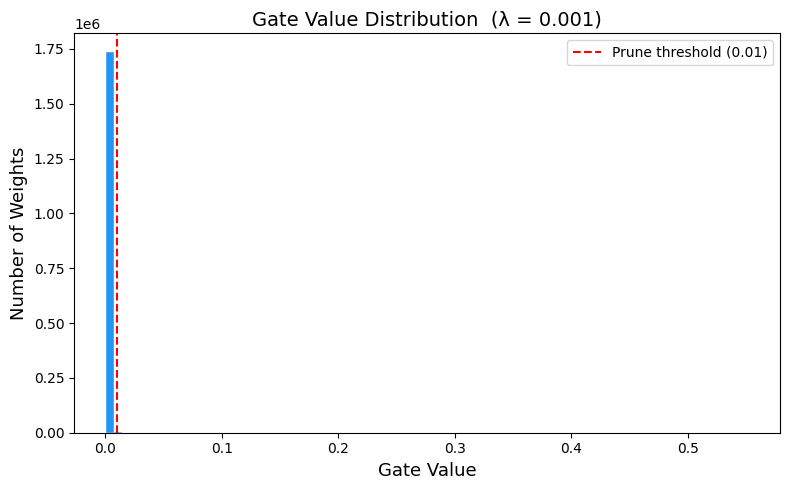

In [7]:
"""
Self-Pruning Neural Network on CIFAR-10
========================================
Author : Your Name
Task   : Tredence AI Engineering Internship Case Study

What this code does (plain English):
  - We build a normal neural network for image classification.
  - BUT every weight has a "gate" attached to it (a number between 0 and 1).
  - If a gate goes to 0, that weight is effectively removed (pruned).
  - We train the network to push most gates to 0 automatically, making the
    network smaller while keeping accuracy as high as possible.
"""

# ── Standard / third-party imports ─────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# ── Reproducibility ─────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── Device: use GPU if available, else CPU ───────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


# ════════════════════════════════════════════════════════════════════════════
# PART 1 – PrunableLinear Layer
# ════════════════════════════════════════════════════════════════════════════

class PrunableLinear(nn.Module):
    """
    A custom linear (fully-connected) layer that can prune its own weights.

    How it works:
      - Normal linear layer: output = input @ weight.T + bias
      - Our layer       : output = input @ (weight * gate).T + bias
        where gate = sigmoid(gate_scores)   ← learned during training

    Because sigmoid always outputs values between 0 and 1:
      - gate ≈ 0  →  weight is effectively removed (pruned)
      - gate ≈ 1  →  weight is kept as-is

    The sparsity loss (defined later) pushes most gates toward 0.
    """

    def __init__(self, in_features: int, out_features: int):
        super().__init__()

        # Standard learnable weight matrix  shape: (out_features, in_features)
        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))

        # Standard learnable bias  shape: (out_features,)
        self.bias = nn.Parameter(torch.Tensor(out_features))

        # Gate scores – same shape as weight – also learnable
        # These are raw (unconstrained) numbers; we pass them through
        # sigmoid in forward() to squeeze them into [0, 1].
        self.gate_scores = nn.Parameter(torch.Tensor(out_features, in_features))

        # Initialise weights with Kaiming uniform (good default for ReLU nets)
        nn.init.kaiming_uniform_(self.weight, nonlinearity="relu")
        nn.init.zeros_(self.bias)
        # Init gate_scores to 2.0 → sigmoid(2.0) ≈ 0.88 (gates start near 1).
        # This is crucial: gates must start HIGH so the sparsity loss has room
        # to push them DOWN toward 0. Starting at 0.5 (sigmoid≈0.62) makes it
        # very hard for the loss to reach 0 in only 30 epochs.
        nn.init.constant_(self.gate_scores, 2.0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Step 1 – squeeze gate_scores into [0, 1]
        gates = torch.sigmoid(self.gate_scores)

        # Step 2 – element-wise multiply: prune weak weights
        pruned_weights = self.weight * gates

        # Step 3 – standard linear operation  (same as F.linear)
        return x @ pruned_weights.T + self.bias

    def get_gates(self) -> torch.Tensor:
        """Return the current gate values (useful for analysis)."""
        return torch.sigmoid(self.gate_scores).detach()


# ════════════════════════════════════════════════════════════════════════════
# Network Definition
# ════════════════════════════════════════════════════════════════════════════

class SelfPruningNet(nn.Module):
    """
    A simple feed-forward network made of PrunableLinear layers.

    Architecture:
      Input (3×32×32 = 3072 floats)
        → PrunableLinear(3072, 512) → BatchNorm → ReLU → Dropout
        → PrunableLinear(512,  256) → BatchNorm → ReLU → Dropout
        → PrunableLinear(256,  128) → BatchNorm → ReLU → Dropout
        → PrunableLinear(128,   10) → (logits, no activation)

    CIFAR-10 has 10 classes, so the last layer has 10 outputs.
    """

    def __init__(self, dropout_rate: float = 0.3):
        super().__init__()

        self.net = nn.Sequential(
            # Block 1
            PrunableLinear(3 * 32 * 32, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Block 2
            PrunableLinear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Block 3
            PrunableLinear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Output layer (no activation – CrossEntropyLoss handles softmax)
            PrunableLinear(128, 10),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Flatten the image: (batch, 3, 32, 32) → (batch, 3072)
        x = x.view(x.size(0), -1)
        return self.net(x)

    def prunable_layers(self):
        """Yield every PrunableLinear layer inside the network."""
        for module in self.modules():
            if isinstance(module, PrunableLinear):
                yield module


# ════════════════════════════════════════════════════════════════════════════
# PART 2 – Sparsity Loss
# ════════════════════════════════════════════════════════════════════════════

def sparsity_loss(model: SelfPruningNet) -> torch.Tensor:
    """
    L1 penalty on all gate values.

    Why L1 encourages sparsity (plain English):
      - L1 = sum of absolute values of gates
      - The gradient of |gate| is always ±1 (constant push toward 0)
      - This gives every gate a constant "nudge" downward
      - Unlike L2 (which slows down near 0), L1 keeps pushing until the gate
        actually hits 0 → true sparsity

    Returns a scalar tensor (the sum of all gate values across all layers).
    """
    total = torch.tensor(0.0, device=DEVICE)
    for layer in model.prunable_layers():
        gates = torch.sigmoid(layer.gate_scores)
        total = total + gates.sum()          # all gates are positive, so |gate| = gate
    return total


# ════════════════════════════════════════════════════════════════════════════
# PART 3 – Data Loading
# ════════════════════════════════════════════════════════════════════════════

def get_dataloaders(batch_size: int = 128):
    """
    Download CIFAR-10 and return train / test DataLoaders.

    Transforms applied:
      Training  : random crop + horizontal flip (data augmentation) + normalize
      Test      : only normalize (no augmentation → fair evaluation)
    """
    # CIFAR-10 mean and std (per channel) – standard values
    mean = (0.4914, 0.4822, 0.4465)
    std  = (0.2023, 0.1994, 0.2010)

    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    train_set = torchvision.datasets.CIFAR10(
        root="./data", train=True,  download=True, transform=train_transform
    )
    test_set  = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True, transform=test_transform
    )

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)

    return train_loader, test_loader


# ════════════════════════════════════════════════════════════════════════════
# Training Loop
# ════════════════════════════════════════════════════════════════════════════

def train(model, train_loader, optimizer, scheduler, lam: float, epochs: int):
    """
    Train the model for a given number of epochs.

    Total Loss = CrossEntropyLoss + λ × SparsityLoss

    Parameters
    ----------
    model        : SelfPruningNet
    train_loader : DataLoader
    optimizer    : e.g. Adam
    scheduler    : learning-rate scheduler
    lam          : λ – controls how hard we push sparsity
    epochs       : number of training epochs
    """
    criterion = nn.CrossEntropyLoss()
    model.train()

    for epoch in range(1, epochs + 1):
        running_loss = 0.0
        correct = 0
        total   = 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()

            # Forward pass
            logits = model(images)

            # Classification loss
            cls_loss = criterion(logits, labels)

            # Sparsity regularisation
            spar_loss = sparsity_loss(model)

            # Combined loss
            loss = cls_loss + lam * spar_loss

            # Backward pass – gradients flow through both weight & gate_scores
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

        scheduler.step()

        train_acc = 100.0 * correct / total
        print(f"  Epoch [{epoch:02d}/{epochs}] "
              f"Loss: {running_loss / len(train_loader):.4f}  "
              f"Train Acc: {train_acc:.2f}%")


# ════════════════════════════════════════════════════════════════════════════
# Evaluation
# ════════════════════════════════════════════════════════════════════════════

def evaluate(model, test_loader):
    """Return test accuracy (%) on the given DataLoader."""
    model.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            preds = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    return 100.0 * correct / total


def compute_sparsity(model, threshold: float = 1e-2) -> float:
    """
    Compute the percentage of weights whose gate value is below `threshold`.

    A gate below the threshold is considered "pruned / dead".

    Returns a float between 0 and 100.
    """
    total_gates  = 0
    pruned_gates = 0

    for layer in model.prunable_layers():
        gates = layer.get_gates()
        total_gates  += gates.numel()
        pruned_gates += (gates < threshold).sum().item()

    return 100.0 * pruned_gates / total_gates


# ════════════════════════════════════════════════════════════════════════════
# Gate Distribution Plot
# ════════════════════════════════════════════════════════════════════════════

def plot_gate_distribution(model, lam: float, save_path: str = None):
    """
    Plot a histogram of all final gate values.

    A well-trained model will show:
      - A large spike near 0  (pruned weights)
      - A smaller cluster near 1  (important weights that survived)
    """
    all_gates = []
    for layer in model.prunable_layers():
        all_gates.append(layer.get_gates().cpu().numpy().flatten())

    all_gates = np.concatenate(all_gates)

    plt.figure(figsize=(8, 5))
    plt.hist(all_gates, bins=80, color="#2196F3", edgecolor="white", linewidth=0.3)
    plt.xlabel("Gate Value", fontsize=13)
    plt.ylabel("Number of Weights", fontsize=13)
    plt.title(f"Gate Value Distribution  (λ = {lam})", fontsize=14)
    plt.axvline(x=0.01, color="red", linestyle="--", label="Prune threshold (0.01)")
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"  Plot saved → {save_path}")
    plt.show()


# ════════════════════════════════════════════════════════════════════════════
# Main – Run experiments for multiple λ values
# ════════════════════════════════════════════════════════════════════════════

def run_experiment(lam: float, train_loader, test_loader, epochs: int = 30):
    """
    Full train → evaluate cycle for one value of λ.

    Returns (test_accuracy, sparsity_level, trained_model)
    """
    print(f"\n{'='*60}")
    print(f"  Experiment: λ = {lam}")
    print(f"{'='*60}")

    model = SelfPruningNet(dropout_rate=0.3).to(DEVICE)

    # Separate parameter groups: gates get a higher LR so they converge faster.
    # Weights use standard 1e-3; gate_scores use 5e-3.
    weight_params = []
    gate_params   = []
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            weight_params += [module.weight, module.bias]
            gate_params.append(module.gate_scores)

    optimizer = optim.Adam([
        {"params": weight_params, "lr": 1e-3,  "weight_decay": 1e-4},
        {"params": gate_params,   "lr": 5e-3,  "weight_decay": 0.0},
    ])

    # Cosine annealing gradually lowers the learning rate → smoother convergence
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train(model, train_loader, optimizer, scheduler, lam=lam, epochs=epochs)

    test_acc = evaluate(model, test_loader)
    sparsity = compute_sparsity(model)

    print(f"\n  ✔ Test Accuracy  : {test_acc:.2f}%")
    print(f"  ✔ Sparsity Level : {sparsity:.2f}%  (gates < 0.01)")

    return test_acc, sparsity, model


def main():
    EPOCHS     = 30          # increase to 50+ for better accuracy
    BATCH_SIZE = 128

    # Three λ values: low / medium / high
    # These must be large enough to overcome the gate's gradient from CrossEntropy.
    # Rule of thumb: sparsity_loss ≈ total_gates ≈ 400k+ so λ must be ≥ 1e-3
    # to produce a meaningful penalty relative to CrossEntropy (~2.3 at start).
    lambda_values = [1e-3, 5e-3, 2e-2]

    train_loader, test_loader = get_dataloaders(batch_size=BATCH_SIZE)

    results = {}   # lam → (test_acc, sparsity, model)

    for lam in lambda_values:
        acc, spar, model = run_experiment(lam, train_loader, test_loader, EPOCHS)
        results[lam] = (acc, spar, model)

    # ── Summary Table ────────────────────────────────────────────────────────
    print("\n" + "="*55)
    print(f"{'Lambda':<12} {'Test Accuracy':>15} {'Sparsity (%)':>15}")
    print("="*55)
    for lam, (acc, spar, _) in results.items():
        print(f"{lam:<12} {acc:>14.2f}% {spar:>14.2f}%")
    print("="*55)

    # ── Gate Distribution Plot for best model (highest accuracy) ─────────────
    best_lam = max(results, key=lambda l: results[l][0])
    best_model = results[best_lam][2]
    print(f"\nPlotting gate distribution for best model (λ = {best_lam}) …")
    plot_gate_distribution(best_model, lam=best_lam,
                           save_path="gate_distribution.png")


if __name__ == "__main__":
    main()